## **Objective**
The bank marketing dataset contains customer information such as age, job, education, account balance, housing loan status, contact details, and previous campaign outcomes. The objective of this notebook is to build a LightGBM Classifier that predicts whether a customer will subscribe to a term deposit. In the target column, `0` represents a customer who did not subscribe, while `1` represents a customer who subscribed. An appropriate evaluation metric will be selected during model tuning based on the objective of the problem. Precision, accuracy, recall, F1-score, and ROC-AUC will be used to evaluate the baseline and tuned models. The training and testing performance of both models will also be compared to check for possible overfitting.

## **Import Libraries**

- Import the libraries required for data handling, visualisation, model building, tuning, and evaluation

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, accuracy_score)
from sklearn.model_selection import GridSearchCV, train_test_split

# **Understanding the Dataset**

## **Task 1**
- Load the bank marketing dataset and display the first few records of the dataset
- Check the column names and their data types
- Check for missing values

In [2]:
df = pd.read_csv('bank.csv'); df.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,deposit
0,59,admin.,married,secondary,no,2343,yes,no,5,may,1042,1,-1,0,yes
1,56,admin.,married,secondary,no,45,no,no,5,may,1467,1,-1,0,yes
2,41,technician,married,secondary,no,1270,yes,no,5,may,1389,1,-1,0,yes
3,55,services,married,secondary,no,2476,yes,no,5,may,579,1,-1,0,yes
4,54,admin.,married,tertiary,no,184,no,no,5,may,673,2,-1,0,yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   day        11162 non-null  int64
 9   month      11162 non-null  str  
 10  duration   11162 non-null  int64
 11  campaign   11162 non-null  int64
 12  pdays      11162 non-null  int64
 13  previous   11162 non-null  int64
 14  deposit    11162 non-null  str  
dtypes: int64(7), str(8)
memory usage: 1.7 MB


In [4]:
missing_values = df.isnull().sum(); missing_values

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
deposit      0
dtype: int64

## **Task 2**
- Display the count of customers who subscribed and did not subscribe using readable labels
- Visualise the number of subscribed and not-subscribed customers using a bar plot

In [5]:
deposit_counts = df['deposit'].map({'no': 'Not Subscribed','yes': 'Subscribed'}).value_counts(); deposit_counts

deposit
Not Subscribed    5873
Subscribed        5289
Name: count, dtype: int64

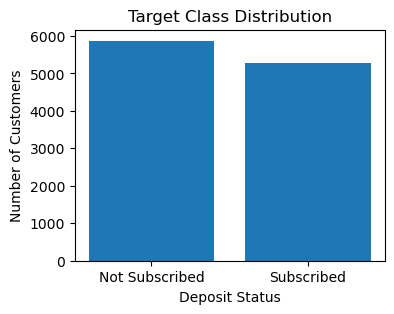

In [6]:
plot_counts = deposit_counts.reindex(['Not Subscribed','Subscribed'])
plt.figure(figsize = (4, 3))
plt.bar(plot_counts.index, plot_counts.values)
plt.title('Target Class Distribution'); plt.xlabel('Deposit Status'); plt.ylabel('Number of Customers')
plt.show()

# **Data Preparation**

## **Task 3**
- Convert the target labels into numerical values

In [7]:
df['deposit'] = df['deposit'].map({'no': 0, 'yes': 1})

## **Task 4**
- Separate the predictor features and target variable
- Create stratified training and testing sets

In [8]:
X = df.drop('deposit', axis = 1); y = df['deposit']
print('Shape of X:', X.shape); print('Shape of y:', y.shape)

Shape of X: (11162, 14)
Shape of y: (11162,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

## **Task 5**
- Encode the categorical training and testing features

In [10]:
X_train_original = X_train.copy(); X_test_original = X_test.copy()
categorical_columns = X_train.select_dtypes(include = 'object').columns
X_train = pd.get_dummies(X_train, columns = categorical_columns, dtype = int)
X_test = pd.get_dummies(X_test, columns = categorical_columns, dtype = int)
X_test = X_test.reindex(columns = X_train.columns, fill_value = 0)
print('Training set shape:', X_train.shape); print('Testing set shape:', X_test.shape)

Training set shape: (8929, 43)
Testing set shape: (2233, 43)


# **Model Training**

## **Task 6**
- Train the baseline LightGBM model using the `n_estimators`, `learning_rate`, `random_state`, and `verbosity` parameters
- Generate training and testing predictions
- Evaluate the baseline model using confusion matrices, accuracy, precision, recall, F1-score, and ROC-AUC

In [11]:
b_model = LGBMClassifier(n_estimators = 100, learning_rate = 0.1, random_state = 42, verbosity = -1)
b_model.fit(X_train, y_train)
b_train_pred = b_model.predict(X_train); b_test_pred = b_model.predict(X_test)
b_train_prob = b_model.predict_proba(X_train)[:, 1]; b_test_prob = b_model.predict_proba(X_test)[:, 1]

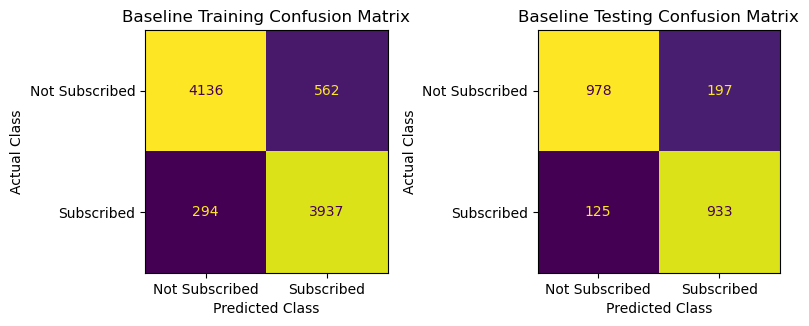

In [12]:
b_train_cm = confusion_matrix(y_train, b_train_pred); b_test_cm = confusion_matrix(y_test, b_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
ConfusionMatrixDisplay(confusion_matrix=b_train_cm, display_labels=['Not Subscribed', 'Subscribed']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Baseline Training Confusion Matrix')
axes[0].set_xlabel('Predicted Class'); axes[0].set_ylabel('Actual Class')
ConfusionMatrixDisplay(confusion_matrix=b_test_cm, display_labels=['Not Subscribed', 'Subscribed']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Baseline Testing Confusion Matrix')
axes[1].set_xlabel('Predicted Class'); axes[1].set_ylabel('Actual Class')
plt.tight_layout()
plt.show()

In [13]:
b_train_acc = accuracy_score(y_train, b_train_pred)
b_train_precision = precision_score(y_train, b_train_pred)
b_train_recall = recall_score(y_train, b_train_pred)
b_train_f1 = f1_score(y_train, b_train_pred)
b_train_roc_auc = roc_auc_score(y_train, b_train_prob)
b_test_acc = accuracy_score(y_test, b_test_pred)
b_test_precision = precision_score(y_test, b_test_pred)
b_test_recall = recall_score(y_test, b_test_pred)
b_test_f1 = f1_score(y_test, b_test_pred)
b_test_roc_auc = roc_auc_score(y_test, b_test_prob)

In [14]:
print('Baseline Training Precision:', round(b_train_precision, 3)); print('Baseline Testing Precision:', round(b_test_precision, 3))
print('\nBaseline Training Recall:', round(b_train_recall, 3)); print('Baseline Testing Recall:', round(b_test_recall, 3))
print('\nBaseline Training F1-Score:', round(b_train_f1, 3)); print('Baseline Testing F1-Score:', round(b_test_f1, 3))
print('\nBaseline Training ROC-AUC:', round(b_train_roc_auc, 3)); print('Baseline Testing ROC-AUC:', round(b_test_roc_auc, 3))
print('\nBaseline Training Accuracy:', round(b_train_acc, 3)); print('Baseline Testing Accuracy:', round(b_test_acc, 3))

Baseline Training Precision: 0.875
Baseline Testing Precision: 0.826

Baseline Training Recall: 0.931
Baseline Testing Recall: 0.882

Baseline Training F1-Score: 0.902
Baseline Testing F1-Score: 0.853

Baseline Training ROC-AUC: 0.97
Baseline Testing ROC-AUC: 0.918

Baseline Training Accuracy: 0.904
Baseline Testing Accuracy: 0.856


## **Task 7**
- Display all parameter values used by the baseline model
- Compare the training and testing values of the selected primary evaluation metric and calculate the performance gap to check for possible overfitting

In [15]:
print(b_model.get_params())

{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbosity': -1}


In [16]:
b_f1_gap = b_train_f1 - b_test_f1
print('F1-Score Gap:', round(b_f1_gap, 3))

F1-Score Gap: 0.049


## **Task 8**
- Display sample customers with their actual and baseline predicted deposit labels

In [17]:
b_pred_df = X_test_original.copy()
b_pred_df['Actual Deposit Status'] = y_test
b_pred_df['Predicted Deposit Status'] = pd.Series(b_test_pred, index = y_test.index)
b_pred_df.sample(10, random_state = 42)

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,Actual Deposit Status,Predicted Deposit Status
7132,34,blue-collar,divorced,secondary,no,1125,yes,yes,19,nov,141,2,-1,0,0,0
1996,42,services,married,secondary,no,146,yes,yes,15,may,670,4,346,1,1,1
1189,53,management,married,tertiary,no,1624,no,no,5,feb,158,3,-1,0,1,0
7445,33,services,single,secondary,no,406,yes,no,5,feb,61,1,275,1,0,0
7979,34,technician,married,secondary,no,484,no,no,9,may,84,4,-1,0,0,0
10388,35,admin.,married,secondary,no,11,yes,no,23,jul,103,4,-1,0,0,0
4230,37,management,married,tertiary,no,57,no,no,5,feb,345,1,-1,0,1,0
10579,38,admin.,single,secondary,no,4023,no,no,11,jun,339,2,-1,0,0,0
10318,31,services,married,secondary,no,418,yes,yes,9,jul,219,1,-1,0,0,0
3662,32,technician,single,tertiary,no,4071,no,no,30,jun,319,2,-1,0,1,1


## **Task 9**
- Display the top five most important features of the baseline LightGBM model

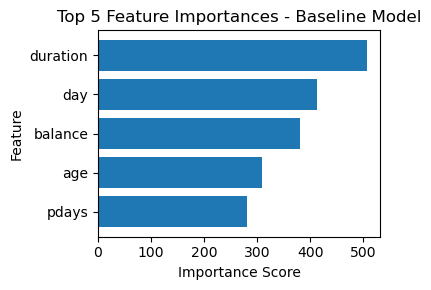

In [18]:
b_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': b_model.feature_importances_})
b_importance = b_importance.sort_values(by = 'Importance', ascending = False).head(5)
plt.figure(figsize = (4, 3))
plt.barh(b_importance['Feature'], b_importance['Importance'])
plt.title('Top 5 Feature Importances - Baseline Model'); plt.xlabel('Importance Score'); plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **Hyperparameter Tuning**

## **Task 10**
- Define suitable values for the `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`, and `min_child_samples` parameters to be tested during LightGBM model tuning


In [19]:
parameter_grid = {'n_estimators': [100, 200], 
                  'learning_rate': [0.05, 0.1, 0.3 , 0.5], 
                  'num_leaves': [15, 31, 37], 
                  'max_depth': [1, 5, 7], 
                  'min_child_samples': [20, 30]}
print(parameter_grid)

{'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1, 0.3, 0.5], 'num_leaves': [15, 31, 37], 'max_depth': [1, 5, 7], 'min_child_samples': [20, 30]}


## **Task 11**
- Select an appropriate scoring metric according to the problem statement and model objective
- Tune the LightGBM model using five-fold cross-validation and the selected scoring metric
- Display the best hyperparameters, best cross-validation score, and best trained model selected by `GridSearchCV`

In [20]:
lightgbm_model = LGBMClassifier(random_state = 42, verbosity = -1)
grid_search = GridSearchCV(estimator = lightgbm_model, 
                           param_grid = parameter_grid, 
                           scoring = 'f1', cv = 5, n_jobs = 1, verbose = 10)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5; 1/144] START learning_rate=0.05, max_depth=1, min_child_samples=20, n_estimators=100, num_leaves=15
[CV 1/5; 1/144] END learning_rate=0.05, max_depth=1, min_child_samples=20, n_estimators=100, num_leaves=15;, score=0.790 total time=   0.0s
[CV 2/5; 1/144] START learning_rate=0.05, max_depth=1, min_child_samples=20, n_estimators=100, num_leaves=15
[CV 2/5; 1/144] END learning_rate=0.05, max_depth=1, min_child_samples=20, n_estimators=100, num_leaves=15;, score=0.771 total time=   0.0s
[CV 3/5; 1/144] START learning_rate=0.05, max_depth=1, min_child_samples=20, n_estimators=100, num_leaves=15
[CV 3/5; 1/144] END learning_rate=0.05, max_depth=1, min_child_samples=20, n_estimators=100, num_leaves=15;, score=0.780 total time=   0.0s
[CV 4/5; 1/144] START learning_rate=0.05, max_depth=1, min_child_samples=20, n_estimators=100, num_leaves=15
[CV 4/5; 1/144] END learning_rate=0.05, max_depth=1, min_child_samples=20, n_esti

,estimator,LGBMClassifie... verbosity=-1)
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [1, 5, ...], 'min_child_samples': [20, 30], 'n_estimators': [100, 200], ...}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,5
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [21]:
print('Best Hyperparameters:'); print(grid_search.best_params_)
print('\nBest Cross-Validation F1-Score:'); print(round(grid_search.best_score_, 3))
print('\nBest Tuned Model:'); print(grid_search.best_estimator_)

Best Hyperparameters:
{'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}

Best Cross-Validation F1-Score:
0.849

Best Tuned Model:
LGBMClassifier(max_depth=7, random_state=42, verbosity=-1)


# **Tuned Model Evaluation and Interpretation**

## **Task 12**
- Store the best tuned LightGBM model and generate predictions and probability scores for the training and testing datasets
- Compare the training and testing values of the selected primary evaluation metric and calculate the performance gap

In [22]:
f_model = grid_search.best_estimator_; f_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,7
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [23]:
f_train_pred = f_model.predict(X_train); f_test_pred = f_model.predict(X_test)
f_train_prob = f_model.predict_proba(X_train)[:, 1]; f_test_prob = f_model.predict_proba(X_test)[:, 1]

In [24]:
f_train_f1 = f1_score(y_train, f_train_pred); f_test_f1 = f1_score(y_test, f_test_pred)
f_f1_gap = f_train_f1 - f_test_f1

print('Training F1-Score:', round(f_train_f1, 3))
print('Testing F1-Score:', round(f_test_f1, 3))
print('F1-Score Gap:', round(f_f1_gap, 3))

Training F1-Score: 0.896
Testing F1-Score: 0.841
F1-Score Gap: 0.055


## **Task 13**
- Display sample customers with their actual deposit labels and the labels predicted by the tuned model

In [25]:
f_pred_df = X_test_original.copy()
f_pred_df['Actual Deposit Status'] = y_test
f_pred_df['Predicted Deposit Status'] = pd.Series(f_test_pred, index = y_test.index)
f_pred_df.sample(10, random_state = 42)

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,Actual Deposit Status,Predicted Deposit Status
7132,34,blue-collar,divorced,secondary,no,1125,yes,yes,19,nov,141,2,-1,0,0,0
1996,42,services,married,secondary,no,146,yes,yes,15,may,670,4,346,1,1,1
1189,53,management,married,tertiary,no,1624,no,no,5,feb,158,3,-1,0,1,0
7445,33,services,single,secondary,no,406,yes,no,5,feb,61,1,275,1,0,0
7979,34,technician,married,secondary,no,484,no,no,9,may,84,4,-1,0,0,0
10388,35,admin.,married,secondary,no,11,yes,no,23,jul,103,4,-1,0,0,0
4230,37,management,married,tertiary,no,57,no,no,5,feb,345,1,-1,0,1,0
10579,38,admin.,single,secondary,no,4023,no,no,11,jun,339,2,-1,0,0,0
10318,31,services,married,secondary,no,418,yes,yes,9,jul,219,1,-1,0,0,0
3662,32,technician,single,tertiary,no,4071,no,no,30,jun,319,2,-1,0,1,1


## **Task 14**
- Create confusion matrices to compare the actual and predicted classes for the tuned model’s training and testing sets

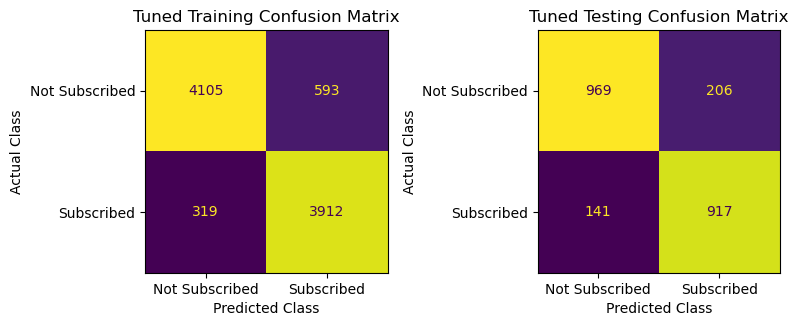

In [26]:
f_train_cm = confusion_matrix(y_train, f_train_pred); f_test_cm = confusion_matrix(y_test, f_test_pred)
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
ConfusionMatrixDisplay(confusion_matrix=f_train_cm, display_labels=['Not Subscribed', 'Subscribed']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Tuned Training Confusion Matrix'); axes[0].set_xlabel('Predicted Class'); axes[0].set_ylabel('Actual Class')
ConfusionMatrixDisplay(confusion_matrix=f_test_cm, display_labels=['Not Subscribed', 'Subscribed']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Tuned Testing Confusion Matrix'); axes[1].set_xlabel('Predicted Class'); axes[1].set_ylabel('Actual Class')
plt.tight_layout()
plt.show()

## **Task 15**
- Evaluate the tuned LightGBM model using accuracy, precision, recall, F1-score, and ROC-AUC

In [27]:
f_train_acc = accuracy_score(y_train, f_train_pred)
f_train_prec = precision_score(y_train, f_train_pred)
f_train_recall = recall_score(y_train, f_train_pred)
f_train_roc_auc = roc_auc_score(y_train, f_train_prob)
f_test_acc = accuracy_score(y_test, f_test_pred)
f_test_prec = precision_score(y_test, f_test_pred)
f_test_recall = recall_score(y_test, f_test_pred)
f_test_roc_auc = roc_auc_score(y_test, f_test_prob)

print('Tuned Training Accuracy:', round(f_train_acc, 3))
print('Tuned Training Precision:', round(f_train_prec, 3))
print('Tuned Training Recall:', round(f_train_recall, 3))
print('Tuned Training F1-Score:', round(f_train_f1, 3))
print('Tuned Training ROC-AUC:', round(f_train_roc_auc, 3))
print('\nTuned Testing Accuracy:', round(f_test_acc, 3))
print('Tuned Testing Precision:', round(f_test_prec, 3))
print('Tuned Testing Recall:', round(f_test_recall, 3))
print('Tuned Testing F1-Score:', round(f_test_f1, 3))
print('Tuned Testing ROC-AUC:', round(f_test_roc_auc, 3))

Tuned Training Accuracy: 0.898
Tuned Training Precision: 0.868
Tuned Training Recall: 0.925
Tuned Training F1-Score: 0.896
Tuned Training ROC-AUC: 0.966

Tuned Testing Accuracy: 0.845
Tuned Testing Precision: 0.817
Tuned Testing Recall: 0.867
Tuned Testing F1-Score: 0.841
Tuned Testing ROC-AUC: 0.919


## **Task 16**
- Plot the training and testing ROC curves for the baseline and tuned LightGBM models

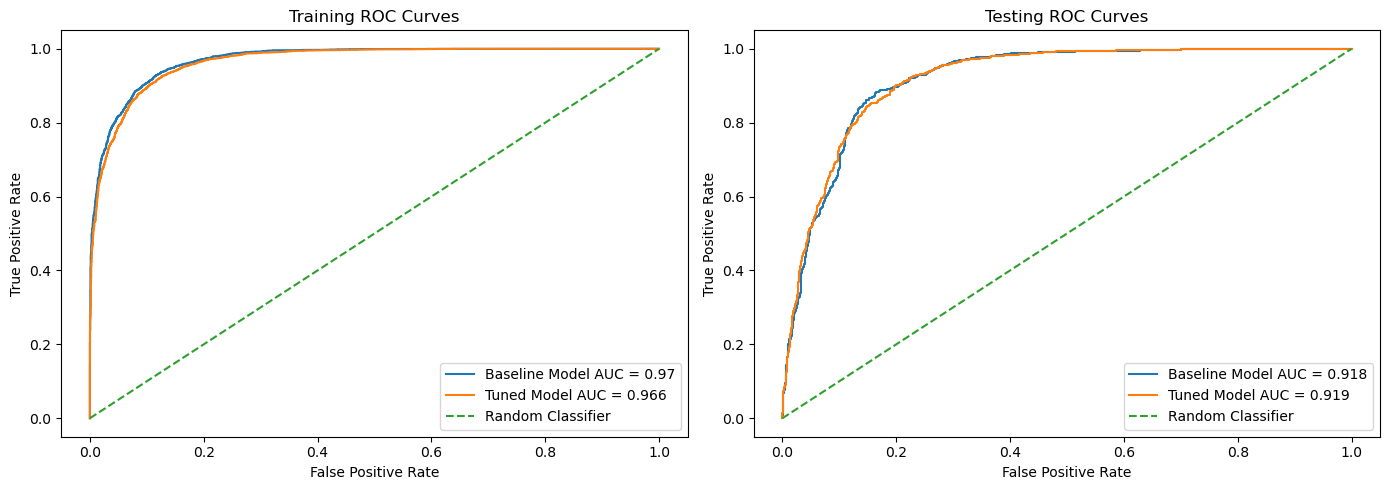

In [28]:
b_train_fpr, b_train_tpr, _ = roc_curve(y_train, b_train_prob); b_test_fpr, b_test_tpr, _ = roc_curve(y_test, b_test_prob)
f_train_fpr, f_train_tpr, _ = roc_curve(y_train, f_train_prob); f_test_fpr, f_test_tpr, _ = roc_curve(y_test, f_test_prob)
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
axes[0].plot(b_train_fpr, b_train_tpr, label = 'Baseline Model AUC = ' + str(round(b_train_roc_auc, 3)))
axes[0].plot(f_train_fpr, f_train_tpr, label = 'Tuned Model AUC = ' + str(round(f_train_roc_auc, 3)))
axes[0].plot([0, 1], [0, 1], linestyle = '--', label = 'Random Classifier')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Training ROC Curves')
axes[0].legend()
axes[1].plot(b_test_fpr, b_test_tpr, label = 'Baseline Model AUC = ' + str(round(b_test_roc_auc, 3)))
axes[1].plot(f_test_fpr, f_test_tpr, label = 'Tuned Model AUC = ' + str(round(f_test_roc_auc, 3)))
axes[1].plot([0, 1], [0, 1], linestyle = '--', label = 'Random Classifier')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Testing ROC Curves')
axes[1].legend()
plt.tight_layout(); plt.show()

## **Task 17**
- Compare the baseline and tuned LightGBM models using accuracy, precision, recall, F1-score, and ROC-AUC, along with the training and testing score gap of the selected metric



In [29]:
model_comparison = pd.DataFrame({
    'Model': ['Baseline Model', 'Tuned Model'],
    'Training Accuracy' : [b_train_acc, f_train_acc],
    'Testing Accuracy' : [b_test_acc, f_test_acc],
    'Training Precision': [b_train_precision, f_train_prec],
    'Testing Precision': [b_test_precision, f_test_prec],
    'Training Recall': [b_train_recall, f_train_recall],
    'Testing Recall': [b_test_recall, f_test_recall],
    'Training F1-Score': [b_train_f1, f_train_f1],
    'Testing F1-Score': [b_test_f1, f_test_f1],
    'F1-Score Gap': [b_f1_gap, f_f1_gap],
    'Training ROC-AUC': [b_train_roc_auc, f_train_roc_auc],
    'Testing ROC-AUC': [b_test_roc_auc, f_test_roc_auc]
})

In [30]:
model_comparison.round(3)

,Model,Training Accuracy,Testing Accuracy,Training Precision,Testing Precision,Training Recall,Testing Recall,Training F1-Score,Testing F1-Score,F1-Score Gap,Training ROC-AUC,Testing ROC-AUC
0,Baseline Model,0.904,0.856,0.875,0.826,0.931,0.882,0.902,0.853,0.049,0.970,0.918
1,Tuned Model,0.898,0.845,0.868,0.817,0.925,0.867,0.896,0.841,0.055,0.966,0.919
